# Lifestyle Habits & Mental Health
### DS4200 Final Project — Northeastern University

**Team:** Emily · Meroska · Aisha  
**Dataset:** ~3,000 global survey responses (Kaggle)  

This notebook contains all visualizations for the project website. Run all cells after placing `Mental_Health_Lifestyle_Dataset.csv` in the same directory.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("Mental_Health_Lifestyle_Dataset.csv")


print(df.shape)
display(df.head())


(3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


<Figure size 800x500 with 0 Axes>

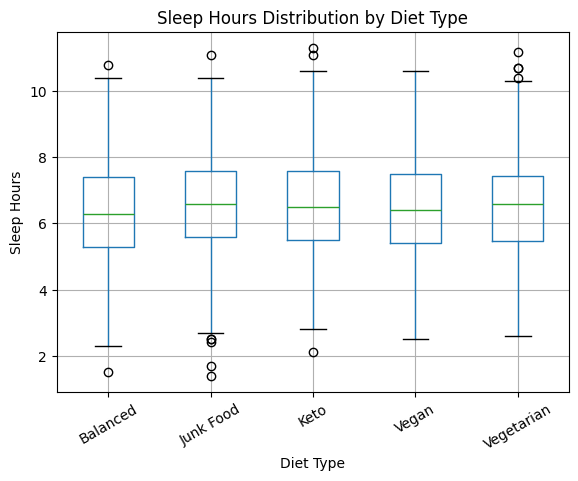

Saved chart_sleep_diet.png


In [4]:
plt.figure(figsize=(8,5))
df.boxplot(column="Sleep Hours", by="Diet Type")

plt.title("Sleep Hours Distribution by Diet Type")
plt.suptitle("")
plt.xlabel("Diet Type")
plt.ylabel("Sleep Hours")
plt.xticks(rotation=30)
plt.savefig('chart_sleep_diet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart_sleep_diet.png')

<Figure size 800x500 with 0 Axes>

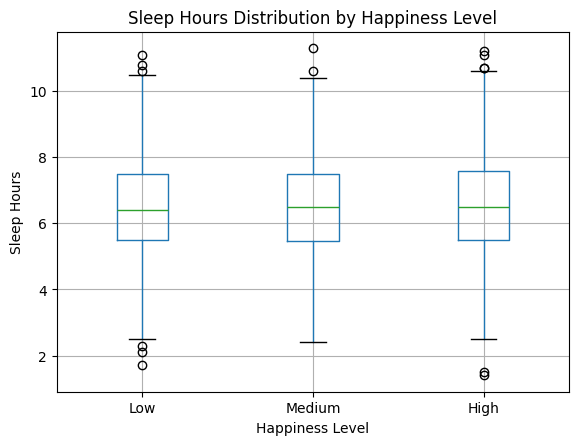

Saved chart_sleep_happiness.png


In [6]:
plt.figure(figsize=(8,5))
df.boxplot(column="Sleep Hours", by="Happiness Level")

plt.title("Sleep Hours Distribution by Happiness Level")
plt.suptitle("")
plt.xlabel("Happiness Level")
plt.ylabel("Sleep Hours")
plt.savefig('chart_sleep_happiness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart_sleep_happiness.png')

In [ ]:
import altair as alt

# Filter dataset to only women
women_data = df[df["Gender"] == "Female"]

In [ ]:

women_data = df[df["Gender"] == "Female"]

chart1 = alt.Chart(women_data).mark_boxplot(size=60).encode(
    x=alt.X("Stress Level:N", title="Stress Level"),
    y=alt.Y("Happiness Score:Q", title="Happiness Score"),
    color="Stress Level:N",
    tooltip=["Stress Level","Happiness Score"]
).properties(
    title="Happiness Scores for Women Across Stress Levels",
    width=400,
    height=400
)

chart1

In [ ]:
chart2 = alt.Chart(women_data).mark_boxplot(size=60).encode(

    x=alt.X("Exercise Level:N", sort=["Low","Moderate","High"], title="Exercise Level"),

    y=alt.Y("Happiness Score:Q", title="Happiness Score"),

    column=alt.Column("Stress Level:N", title="Stress Level"),

    color=alt.Color("Stress Level:N", title="Stress Level"),

    tooltip=["Exercise Level","Happiness Score","Stress Level"]

).properties(
    title="Exercise Level and Happiness for Women Within Each Stress Level",
    width=250,
    height=350
)
chart2

In [ ]:
chart3 = alt.Chart(women_data).mark_boxplot(size=60).encode(

    x=alt.X("Stress Level:N", title="Stress Level"),

    y=alt.Y("Happiness Score:Q", title="Happiness Score"),

    column=alt.Column("Exercise Level:N", sort=["Low","Moderate","High"], title="Exercise Level"),

    color=alt.Color("Stress Level:N", title="Stress Level"),

    tooltip=["Exercise Level","Happiness Score","Stress Level"]

).properties(
    title="Stress Level and Happiness for Women Within Each Exercise Level",
    width=250,
    height=350
)

chart3

In [ ]:
final_chart = chart1 & chart2 & chart3
final_chart

In [ ]:
alt.data_transformers.disable_max_rows()

# Filter data
women_data = df[df["Gender"] == "Female"]

# DROPDOWN PARAM (safe in Colab)
stress_param = alt.param(
    name="stress_filter",
    bind=alt.binding_select(options=["Low", "Moderate", "High"]),
    value="Low"
)

# Filter condition
filter_condition = alt.datum["Stress Level"] == stress_param

# CHART 1
chart1 = alt.Chart(women_data).mark_boxplot(size=60).encode(
    x=alt.X("Stress Level:N"),
    y=alt.Y("Happiness Score:Q"),
    color="Stress Level:N",
    tooltip=["Stress Level", "Happiness Score"]
).add_params(
    stress_param
).properties(
    title="Happiness vs Stress (Women)",
    width=400,
    height=400
)

# CHART 2
chart2 = alt.Chart(women_data).mark_boxplot(size=60).encode(
    x=alt.X("Exercise Level:N", sort=["Low","Moderate","High"]),
    y="Happiness Score:Q",
    column="Stress Level:N",
    color="Stress Level:N",
    tooltip=["Exercise Level","Happiness Score","Stress Level"]
).transform_filter(
    filter_condition
).properties(
    title="Exercise vs Happiness (Filtered)",
    width=250,
    height=350
)

# CHART 3
chart3 = alt.Chart(women_data).mark_boxplot(size=60).encode(
    x="Stress Level:N",
    y="Happiness Score:Q",
    column=alt.Column("Exercise Level:N", sort=["Low","Moderate","High"]),
    color="Stress Level:N",
    tooltip=["Exercise Level","Happiness Score","Stress Level"]
).transform_filter(
    filter_condition
).properties(
    title="Stress vs Happiness by Exercise",
    width=250,
    height=350
)

# DASHBOARD
final_chart = (chart1 | chart2) & chart3

final_chart

The visualizations illustrate the relationship between happiness score, stress level, and exercise level for women. The box plots comparing happiness across stress levels show that median happiness scores are relatively similar for low, moderate, and high stress, with substantial overlap in their distributions, suggesting that stress alone is not a strong predictor of happiness. In contrast, the plots examining exercise level reveal a clearer pattern: higher levels of exercise are generally associated with higher median happiness scores. This trend is consistent even when filtering by stress level, indicating that exercise may positively influence happiness regardless of an individual’s stress level. Additionally, while there is still variability within each group, the upper ranges of happiness scores tend to be higher for those with moderate to high exercise levels. Overall, these results suggest that exercise has a more noticeable and consistent relationship with happiness than stress, supporting the idea that lifestyle factors such as physical activity play an important role in overall well-being.

In [ ]:
alt.data_transformers.disable_max_rows()

# Filter data
women_data = df[df["Gender"] == "Female"].copy()

# ADD JITTER
np.random.seed(1)  # keeps jitter consistent
women_data["jitter"] = np.random.uniform(-0.2, 0.2, size=len(women_data))

# DROPDOWN FILTER
stress_param = alt.param(
    name="stress_filter",
    bind=alt.binding_select(options=["Low", "Moderate", "High"]),
    value="Moderate"
)

# HOVER INTERACTION
hover = alt.selection_point(
    on="mouseover",
    empty="none"
)

# JITTERED SCATTER (STRIP PLOT)
scatter = alt.Chart(women_data).mark_circle(size=80).encode(
    x=alt.X("Exercise Level:N", title="Exercise Level"),
    xOffset="jitter:Q",  # ✅ THIS CREATES THE JITTER
    y=alt.Y("Happiness Score:Q", title="Happiness Score"),
    
    color=alt.Color("Stress Level:N", title="Stress Level"),  # ✅ COLOR
    
    opacity=alt.condition(hover, alt.value(1), alt.value(0.3)),  # ✅ HIGHLIGHT
    
    tooltip=["Exercise Level", "Happiness Score", "Stress Level"]
).add_params(
    stress_param,
    hover
).transform_filter(
    alt.datum["Stress Level"] == stress_param
).properties(
    title="Happiness Distribution by Exercise Level",
    width=500,
    height=400
)

scatter

The scatter plots illustrate the distribution of happiness scores across different exercise levels for women, with the data filtered by stress level. Across all stress levels (low, moderate, and high), happiness scores are widely distributed, indicating significant variability within each exercise group. However, a slight pattern can be observed where individuals with higher exercise levels tend to appear more frequently in the upper range of happiness scores. This trend is most noticeable when comparing low to high exercise levels, where the high exercise group shows a greater concentration of points near higher happiness values. Despite this, there is still substantial overlap between groups, suggesting that while exercise may have a positive relationship with happiness, it is not the sole determining factor. Additionally, the consistency of this pattern across different stress levels indicates that the relationship between exercise and happiness remains relatively stable regardless of stress. Overall, these visualizations suggest that increased exercise is associated with higher happiness, but other factors likely contribute to the overall variation in happiness scores.

In [ ]:
alt.data_transformers.disable_max_rows()

women_data = df[df["Gender"] == "Female"]

# Hover interaction
hover = alt.selection_point(on="mouseover", empty="none")

bar_stress = alt.Chart(women_data).mark_bar().encode(
    x=alt.X("Stress Level:N", title="Stress Level"),
    y=alt.Y("mean(Happiness Score):Q", title="Average Happiness Score"),
    
    color=alt.condition(
        hover,
        alt.Color("Stress Level:N"),
        alt.value("lightgray")   # fade others
    ),
    
    tooltip=[
        "Stress Level",
        alt.Tooltip("mean(Happiness Score):Q", title="Avg Happiness")
    ]
).add_params(
    hover
).properties(
    title="Average Happiness by Stress Level (Women)",
    width=400,
    height=400
)

bar_stress

# Dropdown filter for exercise
exercise_param = alt.param(
    name="exercise_filter",
    bind=alt.binding_select(options=["Low", "Moderate", "High"]),
    value="Moderate"
)

hist_exercise = alt.Chart(women_data).mark_bar().encode(
    x=alt.X(
        "Happiness Score:Q",
        bin=alt.Bin(maxbins=20),
        title="Happiness Score"
    ),
    y=alt.Y("count()", title="Count"),
    
    color=alt.Color("Exercise Level:N"),
    
    tooltip=["count()"]
).add_params(
    exercise_param
).transform_filter(
    alt.datum["Exercise Level"] == exercise_param
).properties(
    title="Happiness Distribution by Exercise Level (Women)",
    width=500,
    height=400
)

hist_exercise

(bar_stress | hist_exercise)

The visualizations compare average happiness across stress levels and the distribution of happiness scores across exercise levels for women. The bar chart shows that average happiness is very similar across low, moderate, and high stress levels, with only slight differences in mean values. This suggests that stress level alone does not strongly impact overall happiness, as all groups have nearly identical averages. In contrast, the histograms reveal more variation in happiness when considering exercise levels. While all exercise groups show a wide spread of happiness scores, higher exercise levels tend to include more observations in the upper range of happiness, indicating a potential positive relationship between exercise and well-being. Additionally, the distributions remain relatively consistent across stress levels, suggesting that the effect of exercise on happiness persists regardless of stress. Overall, these visualizations indicate that exercise may play a more influential role in determining happiness than stress level, although the variability within each group suggests that other factors also contribute to individual differences in happiness.

In [ ]:
alt.data_transformers.disable_max_rows()

women_data = df[df["Gender"] == "Female"]

heatmap = alt.Chart(women_data).mark_rect().encode(
    x=alt.X("Exercise Level:N", title="Exercise Level"),
    y=alt.Y("Stress Level:N", title="Stress Level"),
    
    color=alt.Color(
        "mean(Happiness Score):Q",
        title="Average Happiness",
        scale=alt.Scale(scheme="viridis")
    ),
    
    tooltip=[
        "Exercise Level",
        "Stress Level",
        alt.Tooltip("mean(Happiness Score):Q", title="Avg Happiness")
    ]
).properties(
    title="Average Happiness by Stress and Exercise Level (Women)",
    width=400,
    height=300
)

heatmap

The heatmap visualizes the combined effect of stress level and exercise level on average happiness for women, providing a more comprehensive view than analyzing each factor separately. The color intensity indicates the average happiness score for each combination. Overall, higher exercise levels are generally associated with higher happiness across most stress levels, as seen by the lighter colors in the high exercise column. Notably, individuals with low stress and high exercise exhibit some of the highest happiness levels, suggesting a positive interaction between these factors. In contrast, the combination of low exercise and low stress shows a noticeably lower average happiness, indicating that low physical activity may negatively impact well-being even when stress is minimal. Additionally, for individuals with high stress, increasing exercise appears to improve happiness, suggesting that exercise may help offset the effects of stress. Overall, this visualization highlights that exercise plays a significant role in influencing happiness and can moderate the impact of stress.

In [ ]:
women_data = df[df["Gender"] == "Female"]

# Dropdown filter (optional but nice)
exercise_param = alt.param(
    name="exercise_filter_violin",
    bind=alt.binding_select(options=["Low","Moderate","High"]),
    value="Moderate"
)

violin = alt.Chart(women_data).transform_filter(
    alt.datum["Exercise Level"] == exercise_param
).transform_density(
    "Happiness Score",
    as_=["Happiness Score", "density"],
    groupby=["Stress Level"]
).mark_area(orient="horizontal").encode(
    y=alt.Y("Happiness Score:Q", title="Happiness Score"),
    
    x=alt.X(
        "density:Q",
        stack="center",
        title=None
    ),
    
    color=alt.Color("Stress Level:N", title="Stress Level"),
    
    tooltip=["Stress Level"]
).add_params(
    exercise_param
).properties(
    title="Distribution of Happiness by Stress Level (Filtered by Exercise)",
    width=400,
    height=400
)

violin

---
## Display Full Website
Run the cell below to render the complete project website inline. Make sure `index.html` is in the same folder as this notebook.

In [ ]:
import os
from IPython.display import display, HTML

html_path = "index.html"
if os.path.exists(html_path):
    with open(html_path, 'r', encoding='utf-8') as f:
        html_content = f.read()
    # Escape double quotes for srcdoc attribute
    srcdoc = html_content.replace('&', '&amp;').replace('"', '&quot;')
    display(HTML(f'''
    <div style="width:100%; border:1px solid #e0e0e0; border-radius:12px; overflow:hidden;">
        <iframe srcdoc="{srcdoc}" width="100%" height="950px" style="border:none; display:block;"></iframe>
    </div>
    '''))
else:
    print("index.html not found. Place it in the same folder as this notebook.")


---
## Summary of Findings

**Sleep & Diet (Visualizations 1–2):** Sleep distributions are broadly similar across diet types, with Mediterranean and balanced diets showing slightly higher medians. Individuals with high happiness scores also tend to sleep marginally more.

**Stress & Happiness (Visualization 3):** Median happiness scores are strikingly similar across low, moderate, and high stress levels — stress alone is not a strong predictor of happiness.

**Exercise & Happiness (Visualizations 4–5):** Higher exercise levels are consistently associated with higher median happiness scores, and this holds even when filtering by stress level.

**Strip Plot (Visualization 6):** Individual-level data confirms the exercise–happiness pattern, with higher-exercise individuals concentrated in the upper happiness range across all stress conditions.

**Bar + Histogram (Visualization 7):** Average happiness differs minimally across stress groups (<0.5 pts on a 10-pt scale), while exercise distributions show greater variation in the upper happiness range.

**Heatmap (Visualization 8):** Low exercise + low stress surprisingly yields lower average happiness than expected, suggesting physical activity is independently important for well-being.

**Violin Plot (Visualization 9):** Happiness density distributions across stress levels shift upward with higher exercise, reinforcing the exercise–happiness relationship.

> *All results are correlational. Causal claims cannot be made from this observational dataset.*